In [ ]:
import torch

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

print("=" * 60)

PyTorch Version : 2.11.0+cpu
CUDA Available  : False
Using CPU


In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"divyashreea","key":"64cfd8d5c9baf3358d4bf2642cd9a712"}'}

In [ ]:
!pip -q install monai
!pip -q install nibabel
!pip -q install opencv-python
!pip -q install SimpleITK
!pip -q install torchmetrics
!pip -q install pytorch-fid
!pip -q install opacus
!pip -q install tenseal
!pip -q install kaggle
!pip -q install scikit-image
!pip -q install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 13.1 MB/s eta 0:00:00


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_64090b1e5d08c83aa8c61282a7d3c116"

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [03:28<00:00, 21.5MB/s]



In [ ]:
import zipfile
import os

zip_file = "/content/brats20-dataset-training-validation.zip"
extract_path = "/content/BraTS2020"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/BraTS2020"))

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']


In [ ]:
import os

for root, dirs, files in os.walk("/content/BraTS2020"):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])
    print("-" * 80)

/content/BraTS2020
--------------------------------------------------------------------------------
/content/BraTS2020/BraTS2020_TrainingData
--------------------------------------------------------------------------------
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Files: ['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------------------------------------
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_229
Files: ['BraTS20_Training_229_seg.nii', 'BraTS20_Training_229_t1.nii', 'BraTS20_Training_229_flair.nii', 'BraTS20_Training_229_t2.nii', 'BraTS20_Training_229_t1ce.nii']
--------------------------------------------------------------------------------
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_311
Files: ['BraTS20_Training_311_t2.nii', 'BraTS20_Training_311_t1.nii', 'BraTS20_Training_311_flair.nii', 'BraTS20_Training_311_t1ce.nii', 'B

In [ ]:
import os
import glob

patient_dirs = glob.glob("/content/BraTS2020/**/*.nii", recursive=True)

print("Total NIfTI files:", len(patient_dirs))

Total NIfTI files: 2345


In [ ]:
import os
import glob

patient_folders = sorted(glob.glob("/content/BraTS2020/**/*Training_*", recursive=True))

# Keep only directories
patient_folders = [p for p in patient_folders if os.path.isdir(p)]

print("Total Patient Folders:", len(patient_folders))
print("\nFirst 5 Patient Folders:")

for p in patient_folders[:5]:
    print(p)

Total Patient Folders: 369

First 5 Patient Folders:
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_003
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_004
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_005


In [ ]:
import os
import glob
import nibabel as nib

patient_dir = "/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"

print("Patient folder:")
print(patient_dir)

print("\nFiles found:")
files = sorted(glob.glob(os.path.join(patient_dir, "*.nii*")))

for f in files:
    print(os.path.basename(f))

print("\nImage information:")

for f in files:
    img = nib.load(f)
    print(
        os.path.basename(f),
        "-> Shape:", img.shape,
        "| Data type:", img.get_fdata().dtype
    )

Patient folder:
/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001

Files found:
BraTS20_Training_001_flair.nii
BraTS20_Training_001_seg.nii
BraTS20_Training_001_t1.nii
BraTS20_Training_001_t1ce.nii
BraTS20_Training_001_t2.nii

Image information:
BraTS20_Training_001_flair.nii -> Shape: (240, 240, 155) | Data type: float64
BraTS20_Training_001_seg.nii -> Shape: (240, 240, 155) | Data type: float64
BraTS20_Training_001_t1.nii -> Shape: (240, 240, 155) | Data type: float64
BraTS20_Training_001_t1ce.nii -> Shape: (240, 240, 155) | Data type: float64
BraTS20_Training_001_t2.nii -> Shape: (240, 240, 155) | Data type: float64


In [ ]:
import os
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

# --------------------------------------------------
# Paths
# --------------------------------------------------

patient_dir = "/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"

output_dir = "/content/BraTS2020_Preprocessed"

os.makedirs(output_dir, exist_ok=True)

# --------------------------------------------------
# Patient ID
# --------------------------------------------------

patient_id = "BraTS20_Training_001"

# --------------------------------------------------
# Load MRI modalities
# --------------------------------------------------

flair = nib.load(
    os.path.join(patient_dir, f"{patient_id}_flair.nii")
).get_fdata()

t1 = nib.load(
    os.path.join(patient_dir, f"{patient_id}_t1.nii")
).get_fdata()

t1ce = nib.load(
    os.path.join(patient_dir, f"{patient_id}_t1ce.nii")
).get_fdata()

t2 = nib.load(
    os.path.join(patient_dir, f"{patient_id}_t2.nii")
).get_fdata()

# --------------------------------------------------
# Load segmentation mask
# --------------------------------------------------

seg = nib.load(
    os.path.join(patient_dir, f"{patient_id}_seg.nii")
).get_fdata()

print("Original shapes:")
print("FLAIR :", flair.shape)
print("T1    :", t1.shape)
print("T1ce  :", t1ce.shape)
print("T2    :", t2.shape)
print("Mask  :", seg.shape)


# --------------------------------------------------
# Intensity normalization
# --------------------------------------------------

def normalize_volume(volume):

    # Use non-zero brain voxels
    mask = volume > 0

    if np.sum(mask) == 0:
        return volume.astype(np.float32)

    mean = np.mean(volume[mask])
    std = np.std(volume[mask])

    normalized = np.zeros_like(volume, dtype=np.float32)

    if std > 0:
        normalized[mask] = (volume[mask] - mean) / std

    return normalized


flair = normalize_volume(flair)
t1 = normalize_volume(t1)
t1ce = normalize_volume(t1ce)
t2 = normalize_volume(t2)


# --------------------------------------------------
# Resize to 128 x 128 x 128
# --------------------------------------------------

TARGET_SHAPE = (128, 128, 128)

def resize_volume(volume, target_shape, order=1):

    factors = [
        target_shape[i] / volume.shape[i]
        for i in range(3)
    ]

    return zoom(volume, factors, order=order)


flair = resize_volume(flair, TARGET_SHAPE, order=1)
t1 = resize_volume(t1, TARGET_SHAPE, order=1)
t1ce = resize_volume(t1ce, TARGET_SHAPE, order=1)
t2 = resize_volume(t2, TARGET_SHAPE, order=1)

# For segmentation mask use nearest-neighbour interpolation
seg = resize_volume(seg, TARGET_SHAPE, order=0)


# --------------------------------------------------
# Convert BraTS labels
#
# Original BraTS labels:
# 0 = Background
# 1 = Necrotic/Core
# 2 = Edema
# 4 = Enhancing Tumor
#
# Convert:
# 0 -> 0
# 1 -> 1
# 2 -> 2
# 4 -> 3
# --------------------------------------------------

seg = seg.astype(np.uint8)

seg[seg == 4] = 3


# --------------------------------------------------
# Stack four MRI modalities
# --------------------------------------------------

image = np.stack(
    [flair, t1, t1ce, t2],
    axis=-1
).astype(np.float32)


# --------------------------------------------------
# Save preprocessed data
# --------------------------------------------------

image_path = os.path.join(
    output_dir,
    f"{patient_id}_image.npy"
)

mask_path = os.path.join(
    output_dir,
    f"{patient_id}_mask.npy"
)

np.save(image_path, image)
np.save(mask_path, seg)


# --------------------------------------------------
# Display results
# --------------------------------------------------

print("\nPreprocessing completed.")

print("Preprocessed image shape :", image.shape)
print("Preprocessed mask shape  :", seg.shape)

print("\nMask unique labels:")
print(np.unique(seg))

print("\nSaved files:")
print(image_path)
print(mask_path)

print("\nImage size:", os.path.getsize(image_path) / (1024**2), "MB")
print("Mask size :", os.path.getsize(mask_path) / (1024**2), "MB")

Original shapes:
FLAIR : (240, 240, 155)
T1    : (240, 240, 155)
T1ce  : (240, 240, 155)
T2    : (240, 240, 155)
Mask  : (240, 240, 155)

Preprocessing completed.
Preprocessed image shape : (128, 128, 128, 4)
Preprocessed mask shape  : (128, 128, 128)

Mask unique labels:
[0 1 2 3]

Saved files:
/content/BraTS2020_Preprocessed/BraTS20_Training_001_image.npy
/content/BraTS2020_Preprocessed/BraTS20_Training_001_mask.npy

Image size: 32.0001220703125 MB
Mask size : 2.0001220703125 MB


Image shape: (128, 128, 128, 4)
Mask shape : (128, 128, 128)
Image min: -3.7668893
Image max: 12.886776
Mask labels: [0 1 2 3]


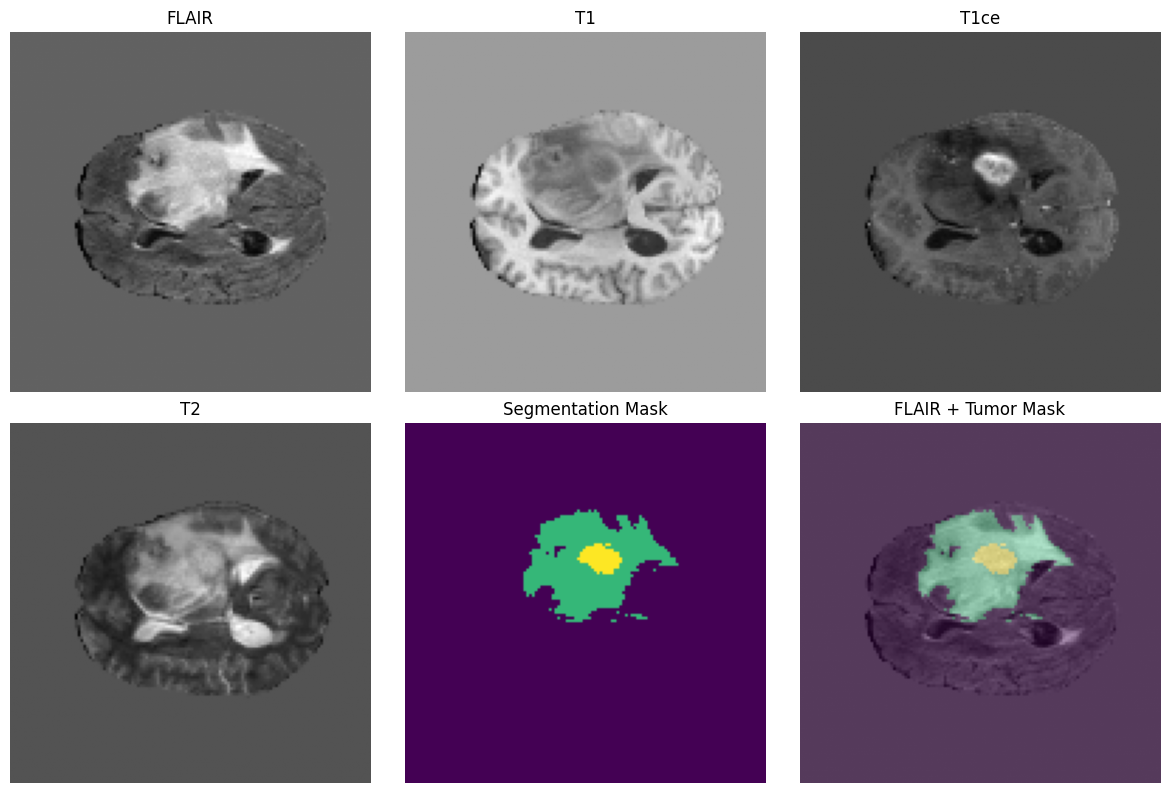

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
image = np.load(
    "/content/BraTS2020_Preprocessed/BraTS20_Training_001_image.npy"
)

mask = np.load(
    "/content/BraTS2020_Preprocessed/BraTS20_Training_001_mask.npy"
)

print("Image shape:", image.shape)
print("Mask shape :", mask.shape)

print("Image min:", image.min())
print("Image max:", image.max())

print("Mask labels:", np.unique(mask))

# Select middle slice
slice_idx = 64

# MRI modalities
flair = image[:, :, slice_idx, 0]
t1 = image[:, :, slice_idx, 1]
t1ce = image[:, :, slice_idx, 2]
t2 = image[:, :, slice_idx, 3]

# Mask
mask_slice = mask[:, :, slice_idx]

# Plot
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(flair, cmap="gray")
plt.title("FLAIR")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(t1, cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(t1ce, cmap="gray")
plt.title("T1ce")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(t2, cmap="gray")
plt.title("T2")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask_slice)
plt.title("Segmentation Mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(flair, cmap="gray")
plt.imshow(mask_slice, alpha=0.4)
plt.title("FLAIR + Tumor Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
from tqdm import tqdm
import shutil

# ============================================================
# PATHS
# ============================================================

DATA_ROOT = "/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

OUTPUT_ROOT = "/content/BraTS2020_Preprocessed_All"

os.makedirs(OUTPUT_ROOT, exist_ok=True)


# ============================================================
# TARGET SIZE
# ============================================================

TARGET_SHAPE = (128, 128, 128)


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_volume(volume):

    mask = volume > 0

    if np.sum(mask) == 0:
        return volume.astype(np.float32)

    mean = np.mean(volume[mask])
    std = np.std(volume[mask])

    normalized = np.zeros_like(volume, dtype=np.float32)

    if std > 0:
        normalized[mask] = (volume[mask] - mean) / std

    return normalized


# ============================================================
# RESIZE
# ============================================================

def resize_volume(volume, target_shape, order):

    factors = [
        target_shape[i] / volume.shape[i]
        for i in range(3)
    ]

    return zoom(volume, factors, order=order)


# ============================================================
# FIND PATIENTS
# ============================================================

patient_folders = sorted(
    glob.glob(
        os.path.join(DATA_ROOT, "BraTS20_Training_*")
    )
)

print("Total patients found:", len(patient_folders))


# ============================================================
# PROCESS ALL PATIENTS
# ============================================================

successful = 0
failed = []

for patient_dir in tqdm(patient_folders, desc="Preprocessing patients"):

    patient_id = os.path.basename(patient_dir)

    try:

        # ----------------------------------------------------
        # File paths
        # ----------------------------------------------------

        flair_path = os.path.join(
            patient_dir,
            f"{patient_id}_flair.nii"
        )

        t1_path = os.path.join(
            patient_dir,
            f"{patient_id}_t1.nii"
        )

        t1ce_path = os.path.join(
            patient_dir,
            f"{patient_id}_t1ce.nii"
        )

        t2_path = os.path.join(
            patient_dir,
            f"{patient_id}_t2.nii"
        )

        seg_path = os.path.join(
            patient_dir,
            f"{patient_id}_seg.nii"
        )

        # ----------------------------------------------------
        # Load MRI
        # ----------------------------------------------------

        flair = nib.load(flair_path).get_fdata()
        t1 = nib.load(t1_path).get_fdata()
        t1ce = nib.load(t1ce_path).get_fdata()
        t2 = nib.load(t2_path).get_fdata()

        # ----------------------------------------------------
        # Load segmentation
        # ----------------------------------------------------

        seg = nib.load(seg_path).get_fdata()

        # ----------------------------------------------------
        # Normalize MRI modalities
        # ----------------------------------------------------

        flair = normalize_volume(flair)
        t1 = normalize_volume(t1)
        t1ce = normalize_volume(t1ce)
        t2 = normalize_volume(t2)

        # ----------------------------------------------------
        # Resize MRI
        # ----------------------------------------------------

        flair = resize_volume(
            flair,
            TARGET_SHAPE,
            order=1
        )

        t1 = resize_volume(
            t1,
            TARGET_SHAPE,
            order=1
        )

        t1ce = resize_volume(
            t1ce,
            TARGET_SHAPE,
            order=1
        )

        t2 = resize_volume(
            t2,
            TARGET_SHAPE,
            order=1
        )

        # ----------------------------------------------------
        # Resize segmentation
        # Nearest-neighbour interpolation
        # ----------------------------------------------------

        seg = resize_volume(
            seg,
            TARGET_SHAPE,
            order=0
        )

        # ----------------------------------------------------
        # Convert labels
        #
        # Original:
        # 0 = Background
        # 1 = Necrotic/Core
        # 2 = Edema
        # 4 = Enhancing Tumor
        #
        # New:
        # 0 = Background
        # 1 = Necrotic/Core
        # 2 = Edema
        # 3 = Enhancing Tumor
        # ----------------------------------------------------

        seg = seg.astype(np.uint8)

        seg[seg == 4] = 3

        # ----------------------------------------------------
        # Stack MRI modalities
        # Shape = (128,128,128,4)
        # ----------------------------------------------------

        image = np.stack(
            [
                flair,
                t1,
                t1ce,
                t2
            ],
            axis=-1
        ).astype(np.float32)

        # ----------------------------------------------------
        # Save patient directory
        # ----------------------------------------------------

        patient_output = os.path.join(
            OUTPUT_ROOT,
            patient_id
        )

        os.makedirs(
            patient_output,
            exist_ok=True
        )

        # ----------------------------------------------------
        # Save image
        # ----------------------------------------------------

        np.save(
            os.path.join(
                patient_output,
                "image.npy"
            ),
            image
        )

        # ----------------------------------------------------
        # Save mask
        # ----------------------------------------------------

        np.save(
            os.path.join(
                patient_output,
                "mask.npy"
            ),
            seg
        )

        successful += 1

    except Exception as e:

        failed.append(
            (
                patient_id,
                str(e)
            )
        )


# ============================================================
# SUMMARY
# ============================================================

print("\n========================================")
print("PREPROCESSING COMPLETED")
print("========================================")

print("Total patients :", len(patient_folders))
print("Successful     :", successful)
print("Failed         :", len(failed))

if failed:

    print("\nFailed patients:")

    for patient_id, error in failed:
        print(patient_id, "->", error)

else:

    print("\nAll patients processed successfully.")


# ============================================================
# CHECK ONE OUTPUT
# ============================================================

example_patient = os.path.join(
    OUTPUT_ROOT,
    "BraTS20_Training_001"
)

example_image = np.load(
    os.path.join(
        example_patient,
        "image.npy"
    )
)

example_mask = np.load(
    os.path.join(
        example_patient,
        "mask.npy"
    )
)

print("\nExample patient:")
print("Image shape :", example_image.shape)
print("Mask shape  :", example_mask.shape)
print("Mask labels :", np.unique(example_mask))

Total patients found: 369


Preprocessing patients: 100%|██████████| 369/369 [11:09<00:00,  1.81s/it]



PREPROCESSING COMPLETED
Total patients : 369
Successful     : 368
Failed         : 1

Failed patients:
BraTS20_Training_355 -> No such file or no access: '/content/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_355/BraTS20_Training_355_seg.nii'

Example patient:
Image shape : (128, 128, 128, 4)
Mask shape  : (128, 128, 128)
Mask labels : [0 1 2 3]


In [ ]:
import os
import shutil

# --------------------------------------------------
# Preprocessed dataset folder
# --------------------------------------------------

PREPROCESSED_DIR = "/content/BraTS2020_Preprocessed_All"

# --------------------------------------------------
# ZIP output
# --------------------------------------------------

ZIP_PATH = "/content/BraTS2020_Preprocessed_All"

# Create ZIP file
zip_file = shutil.make_archive(
    ZIP_PATH,
    "zip",
    PREPROCESSED_DIR
)

print("ZIP file created successfully!")
print(zip_file)

# Check size
size_gb = os.path.getsize(zip_file) / (1024 ** 3)

print("ZIP size:", round(size_gb, 2), "GB")

ZIP file created successfully!
/content/BraTS2020_Preprocessed_All.zip
ZIP size: 1.82 GB


In [ ]:
import os

zip_file = "/content/BraTS2020_Preprocessed_All.zip"

print("Exists:", os.path.exists(zip_file))

if os.path.exists(zip_file):
    print(
        "File size:",
        round(os.path.getsize(zip_file) / (1024 ** 3), 2),
        "GB"
    )

Exists: True
File size: 1.82 GB


In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================

DATA_ROOT = (
    "/content/BraTS2020/"
    "BraTS2020_TrainingData/"
    "MICCAI_BraTS2020_TrainingData"
)

OUTPUT_ROOT = "/content/BraTS2020_Preprocessed"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

TARGET_SHAPE = (128, 128, 128)


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_volume(volume):

    # IMPORTANT:
    # Convert explicitly to float32
    volume = np.asarray(volume, dtype=np.float32)

    brain = volume > 0

    if not np.any(brain):
        return np.zeros(
            volume.shape,
            dtype=np.float32
        )

    mean = np.mean(volume[brain], dtype=np.float32)
    std = np.std(volume[brain], dtype=np.float32)

    if std > 0:
        volume[brain] = (
            volume[brain] - mean
        ) / std

    volume[~brain] = 0

    return volume.astype(np.float32)


# ============================================================
# RESIZE
# ============================================================

def resize_volume(volume, order):

    volume = np.asarray(
        volume,
        dtype=np.float32
    )

    factors = (
        TARGET_SHAPE[0] / volume.shape[0],
        TARGET_SHAPE[1] / volume.shape[1],
        TARGET_SHAPE[2] / volume.shape[2]
    )

    resized = zoom(
        volume,
        factors,
        order=order
    )

    return resized.astype(np.float32)


# ============================================================
# PATIENTS
# ============================================================

patients = sorted(
    glob.glob(
        os.path.join(
            DATA_ROOT,
            "BraTS20_Training_*"
        )
    )
)

print("Total patients:", len(patients))


# ============================================================
# PROCESS
# ============================================================

successful = 0
failed = []

# For the conference experiment,
# process only the first 50 patients initially.

patients_to_process = patients[:50]

print(
    "Patients selected for experiment:",
    len(patients_to_process)
)


for patient_dir in tqdm(
    patients_to_process,
    desc="Preprocessing"
):

    patient_id = os.path.basename(
        patient_dir
    )

    try:

        # ----------------------------------------------------
        # Load MRI
        # ----------------------------------------------------

        flair = nib.load(
            os.path.join(
                patient_dir,
                f"{patient_id}_flair.nii"
            )
        ).get_fdata(dtype=np.float32)

        t1 = nib.load(
            os.path.join(
                patient_dir,
                f"{patient_id}_t1.nii"
            )
        ).get_fdata(dtype=np.float32)

        t1ce = nib.load(
            os.path.join(
                patient_dir,
                f"{patient_id}_t1ce.nii"
            )
        ).get_fdata(dtype=np.float32)

        t2 = nib.load(
            os.path.join(
                patient_dir,
                f"{patient_id}_t2.nii"
            )
        ).get_fdata(dtype=np.float32)

        seg = nib.load(
            os.path.join(
                patient_dir,
                f"{patient_id}_seg.nii"
            )
        ).get_fdata(dtype=np.float32)


        # ----------------------------------------------------
        # Normalize
        # ----------------------------------------------------

        flair = normalize_volume(flair)
        t1 = normalize_volume(t1)
        t1ce = normalize_volume(t1ce)
        t2 = normalize_volume(t2)


        # ----------------------------------------------------
        # Resize MRI
        # ----------------------------------------------------

        flair = resize_volume(
            flair,
            order=1
        )

        t1 = resize_volume(
            t1,
            order=1
        )

        t1ce = resize_volume(
            t1ce,
            order=1
        )

        t2 = resize_volume(
            t2,
            order=1
        )


        # ----------------------------------------------------
        # Resize mask
        # ----------------------------------------------------

        seg = resize_volume(
            seg,
            order=0
        )

        # ----------------------------------------------------
        # Convert labels
        # ----------------------------------------------------

        seg = seg.astype(
            np.uint8
        )

        seg[seg == 4] = 3


        # ----------------------------------------------------
        # Stack modalities
        # ----------------------------------------------------

        image = np.stack(
            [
                flair,
                t1,
                t1ce,
                t2
            ],
            axis=-1
        )

        # Use float16 to reduce storage
        image = image.astype(
            np.float16
        )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        output_file = os.path.join(
            OUTPUT_ROOT,
            f"{patient_id}.npz"
        )

        np.savez_compressed(
            output_file,
            image=image,
            mask=seg
        )

        successful += 1


    except Exception as e:

        failed.append(
            (
                patient_id,
                str(e)
            )
        )


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("PREPROCESSING COMPLETED")
print("===================================")

print(
    "Selected patients :",
    len(patients_to_process)
)

print(
    "Successful        :",
    successful
)

print(
    "Failed            :",
    len(failed)
)


if failed:

    print("\nFailed patients:")

    for patient_id, error in failed:
        print(
            patient_id,
            "->",
            error
        )


# ============================================================
# VERIFY
# ============================================================

if successful > 0:

    test_file = os.path.join(
        OUTPUT_ROOT,
        "BraTS20_Training_001.npz"
    )

    if os.path.exists(test_file):

        data = np.load(
            test_file
        )

        image = data["image"]
        mask = data["mask"]

        print("\n===================================")
        print("FIRST PATIENT CHECK")
        print("===================================")

        print(
            "Image shape :",
            image.shape
        )

        print(
            "Image dtype :",
            image.dtype
        )

        print(
            "Mask shape  :",
            mask.shape
        )

        print(
            "Mask dtype  :",
            mask.dtype
        )

        print(
            "Mask labels :",
            np.unique(mask)
        )

        print(
            "File size   :",
            round(
                os.path.getsize(
                    test_file
                ) / (1024 ** 2),
                2
            ),
            "MB"
        )

Total patients: 369
Patients selected for experiment: 50


Preprocessing: 100%|██████████| 50/50 [01:47<00:00,  2.14s/it]


PREPROCESSING COMPLETED
Selected patients : 50
Successful        : 50
Failed            : 0

FIRST PATIENT CHECK
Image shape : (128, 128, 128, 4)
Image dtype : float16
Mask shape  : (128, 128, 128)
Mask dtype  : uint8
Mask labels : [0 1 2 3]
File size   : 2.35 MB


In [ ]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "/content/BraTS2020_Preprocessed"

NUM_CLASSES = 4
BATCH_SIZE = 1
EPOCHS = 3
LEARNING_RATE = 1e-4

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# FILES
# ============================================================

files = sorted(
    glob.glob(
        os.path.join(
            DATA_DIR,
            "*.npz"
        )
    )
)

print("Total files:", len(files))

# Shuffle reproducibly
random.shuffle(files)

# 40 training + 10 validation
train_files = files[:40]
val_files = files[40:50]

print("Training patients  :", len(train_files))
print("Validation patients:", len(val_files))


# ============================================================
# DATASET
# ============================================================

class BraTSDataset(Dataset):

    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):

        data = np.load(
            self.files[index]
        )

        image = data["image"]
        mask = data["mask"]

        # (128,128,128,4)
        # ->
        # (4,128,128,128)

        image = np.transpose(
            image,
            (3, 0, 1, 2)
        )

        image = torch.from_numpy(
            image.astype(np.float32)
        )

        mask = torch.from_numpy(
            mask.astype(np.int64)
        )

        return image, mask


train_dataset = BraTSDataset(
    train_files
)

val_dataset = BraTSDataset(
    val_files
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)


# ============================================================
# LIGHTWEIGHT 3D U-NET
# ============================================================

class DoubleConv3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.block(x)


class UNet3D(nn.Module):

    def __init__(
        self,
        num_classes=4
    ):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv3D(
            4,
            16
        )

        self.enc2 = DoubleConv3D(
            16,
            32
        )

        self.enc3 = DoubleConv3D(
            32,
            64
        )

        # Bottleneck
        self.bottleneck = DoubleConv3D(
            64,
            128
        )

        # Pooling
        self.pool = nn.MaxPool3d(
            2
        )

        # Decoder
        self.up3 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv3D(
            128,
            64
        )

        self.up2 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv3D(
            64,
            32
        )

        self.up1 = nn.ConvTranspose3d(
            32,
            16,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv3D(
            32,
            16
        )

        # Output
        self.out = nn.Conv3d(
            16,
            num_classes,
            kernel_size=1
        )


    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e3)
        )

        # Decoder
        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)


# ============================================================
# MODEL
# ============================================================

model = UNet3D(
    num_classes=NUM_CLASSES
).to(device)

print("\nModel created.")

parameters = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "Trainable parameters:",
    f"{parameters:,}"
)


# ============================================================
# DICE LOSS
# ============================================================

def dice_loss(
    prediction,
    target,
    smooth=1e-5
):

    probability = F.softmax(
        prediction,
        dim=1
    )

    target_one_hot = F.one_hot(
        target,
        NUM_CLASSES
    )

    target_one_hot = target_one_hot.permute(
        0,
        4,
        1,
        2,
        3
    ).float()

    intersection = (
        probability * target_one_hot
    ).sum(
        dim=(2, 3, 4)
    )

    denominator = (
        probability.sum(
            dim=(2, 3, 4)
        )
        +
        target_one_hot.sum(
            dim=(2, 3, 4)
        )
    )

    dice = (
        (2 * intersection + smooth)
        /
        (denominator + smooth)
    )

    return 1 - dice.mean()


# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion_ce = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# METRICS
# ============================================================

def calculate_dice(
    prediction,
    target
):

    prediction = torch.argmax(
        prediction,
        dim=1
    )

    scores = []

    for cls in range(NUM_CLASSES):

        pred_cls = (
            prediction == cls
        )

        target_cls = (
            target == cls
        )

        intersection = (
            pred_cls & target_cls
        ).sum().float()

        denominator = (
            pred_cls.sum()
            +
            target_cls.sum()
        ).float()

        if denominator == 0:

            dice = torch.tensor(
                1.0,
                device=prediction.device
            )

        else:

            dice = (
                2 * intersection
                /
                denominator
            )

        scores.append(
            dice.item()
        )

    return np.mean(scores)


# ============================================================
# TRAINING
# ============================================================

best_val_dice = 0.0

print("\n======================================")
print("STARTING TRAINING")
print("======================================")

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        ce_loss = criterion_ce(
            outputs,
            masks
        )

        d_loss = dice_loss(
            outputs,
            masks
        )

        loss = (
            ce_loss
            +
            d_loss
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    train_loss /= len(
        train_loader
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            ce_loss = criterion_ce(
                outputs,
                masks
            )

            d_loss = dice_loss(
                outputs,
                masks
            )

            loss = (
                ce_loss
                +
                d_loss
            )

            val_loss += loss.item()

            val_dice += calculate_dice(
                outputs,
                masks
            )


    val_loss /= len(
        val_loader
    )

    val_dice /= len(
        val_loader
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        torch.save(
            model.state_dict(),
            "/content/best_3D_UNet_BraTS2020.pth"
        )


    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Dice: {val_dice:.4f}"
    )


print("\n======================================")
print("TRAINING COMPLETED")
print("======================================")

print(
    "Best validation Dice:",
    round(best_val_dice, 4)
)

print(
    "Model saved:",
    os.path.exists(
        "/content/best_3D_UNet_BraTS2020.pth"
    )
)

Device: cpu
Total files: 50
Training patients  : 40
Validation patients: 10

Model created.
Trainable parameters: 1,402,612

STARTING TRAINING
Epoch [1/3] Train Loss: 2.0888 Val Loss: 1.9865 Val Dice: 0.3282
Epoch [2/3] Train Loss: 1.9481 Val Loss: 1.9280 Val Dice: 0.3837
Epoch [3/3] Train Loss: 1.8638 Val Loss: 1.8980 Val Dice: 0.5063

TRAINING COMPLETED
Best validation Dice: 0.5063
Model saved: True


In [ ]:
# ============================================================
# FINAL RESULTS ONLY
# ============================================================

import numpy as np
import torch

model.eval()

results = []
class_dice = [[] for _ in range(4)]

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model(images)

        pred = torch.argmax(
            outputs,
            dim=1
        )[0].cpu().numpy()

        true = masks[0].numpy()

        patient_metrics = []

        for cls in range(4):

            p = pred == cls
            t = true == cls

            tp = np.logical_and(p, t).sum()
            fp = np.logical_and(p, ~t).sum()
            fn = np.logical_and(~p, t).sum()
            tn = np.logical_and(~p, ~t).sum()

            dice = 2 * tp / (
                2 * tp + fp + fn + 1e-8
            )

            iou = tp / (
                tp + fp + fn + 1e-8
            )

            precision = tp / (
                tp + fp + 1e-8
            )

            recall = tp / (
                tp + fn + 1e-8
            )

            f1 = 2 * precision * recall / (
                precision + recall + 1e-8
            )

            accuracy = (
                tp + tn
            ) / (
                tp + tn + fp + fn + 1e-8
            )

            class_dice[cls].append(dice)

            patient_metrics.append([
                dice,
                iou,
                precision,
                recall,
                f1,
                accuracy
            ])

        results.append(
            np.mean(
                patient_metrics,
                axis=0
            )
        )


results = np.mean(
    results,
    axis=0
)

print("\n======================================")
print("FINAL VALIDATION RESULTS")
print("======================================")

print(f"Accuracy  : {results[5]:.4f}")
print(f"Precision : {results[2]:.4f}")
print(f"Recall    : {results[3]:.4f}")
print(f"F1-score  : {results[4]:.4f}")
print(f"Dice      : {results[0]:.4f}")
print(f"IoU       : {results[1]:.4f}")

print("\n======================================")
print("CLASS-WISE DICE")
print("======================================")

names = [
    "Background",
    "Necrotic/Core",
    "Edema",
    "Enhancing Tumor"
]

for i in range(4):

    print(
        f"{names[i]:20s}: "
        f"{np.mean(class_dice[i]):.4f} ± "
        f"{np.std(class_dice[i]):.4f}"
    )


FINAL VALIDATION RESULTS
Accuracy  : 0.9933
Precision : 0.4707
Recall    : 0.6360
F1-score  : 0.5063
Dice      : 0.5063
IoU       : 0.4174

CLASS-WISE DICE
Background          : 0.9945 ± 0.0042
Necrotic/Core       : 0.2068 ± 0.1085
Edema               : 0.5321 ± 0.1935
Enhancing Tumor     : 0.2918 ± 0.1029


In [ ]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/content/BraTS2020_Preprocessed"
MODEL_PATH = "/content/best_3D_UNet_BraTS2020.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load the EXACT validation split used during training
SPLIT_PATH = "/content/BraTS2020_Results/train_validation_split.json"

with open(SPLIT_PATH, "r") as f:
    split = json.load(f)

val_files = split["validation"]

print("Device:", device)
print("Validation patients:", len(val_files))


class Dataset3D(Dataset):

    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):

        data = np.load(self.files[i])

        image = data["image"]
        mask = data["mask"]

        image = np.transpose(
            image,
            (3, 0, 1, 2)
        )

        return (
            torch.tensor(image, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.long)
        )


class ConvBlock(nn.Module):

    def __init__(self, a, b):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv3d(a, b, 3, padding=1),
            nn.BatchNorm3d(b),
            nn.ReLU(inplace=True),

            nn.Conv3d(b, b, 3, padding=1),
            nn.BatchNorm3d(b),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet3D(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ConvBlock(4, 16)
        self.e2 = ConvBlock(16, 32)
        self.e3 = ConvBlock(32, 64)

        self.b = ConvBlock(64, 128)

        self.pool = nn.MaxPool3d(2)

        self.u3 = nn.ConvTranspose3d(
            128, 64, 2, 2
        )

        self.d3 = ConvBlock(128, 64)

        self.u2 = nn.ConvTranspose3d(
            64, 32, 2, 2
        )

        self.d2 = ConvBlock(64, 32)

        self.u1 = nn.ConvTranspose3d(
            32, 16, 2, 2
        )

        self.d1 = ConvBlock(32, 16)

        self.out = nn.Conv3d(
            16, 4, 1
        )

    def forward(self, x):

        e1 = self.e1(x)

        e2 = self.e2(
            self.pool(e1)
        )

        e3 = self.e3(
            self.pool(e2)
        )

        b = self.b(
            self.pool(e3)
        )

        d3 = self.u3(b)
        d3 = self.d3(
            torch.cat([d3, e3], 1)
        )

        d2 = self.u2(d3)
        d2 = self.d2(
            torch.cat([d2, e2], 1)
        )

        d1 = self.u1(d2)
        d1 = self.d1(
            torch.cat([d1, e1], 1)
        )

        return self.out(d1)


model = UNet3D().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

loader = DataLoader(
    Dataset3D(val_files),
    batch_size=1,
    shuffle=False
)

print("Model loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/BraTS2020_Results/train_validation_split.json'

In [ ]:
def calculate_metrics(pred, true):

    tp = np.logical_and(pred, true).sum()
    fp = np.logical_and(pred, ~true).sum()
    fn = np.logical_and(~pred, true).sum()
    tn = np.logical_and(~pred, ~true).sum()

    dice = (
        2 * tp /
        (2 * tp + fp + fn + 1e-8)
    )

    iou = (
        tp /
        (tp + fp + fn + 1e-8)
    )

    precision = (
        tp /
        (tp + fp + 1e-8)
    )

    recall = (
        tp /
        (tp + fn + 1e-8)
    )

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-8)
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn + 1e-8)
    )

    return [
        dice,
        iou,
        precision,
        recall,
        f1,
        accuracy
    ]


class_names = [
    "Background",
    "Necrotic/Core",
    "Edema",
    "Enhancing Tumor"
]

all_results = []

class_dice = [
    [] for _ in range(4)
]


with torch.no_grad():

    for images, masks in loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        pred = predictions[0].cpu().numpy()
        true = masks[0].numpy()

        patient_results = []

        for cls in range(4):

            pred_class = pred == cls
            true_class = true == cls

            metrics = calculate_metrics(
                pred_class,
                true_class
            )

            patient_results.append(metrics)

            class_dice[cls].append(
                metrics[0]
            )

        # Average across four classes
        patient_results = np.mean(
            patient_results,
            axis=0
        )

        all_results.append(
            patient_results
        )


all_results = np.array(
    all_results
)

final_metrics = np.mean(
    all_results,
    axis=0
)

print("Metric calculation completed.")

In [ ]:
print("\n" + "=" * 50)
print("FINAL VALIDATION RESULTS")
print("=" * 50)

print(
    f"Accuracy   : {final_metrics[5]:.4f}"
)

print(
    f"Precision  : {final_metrics[2]:.4f}"
)

print(
    f"Recall     : {final_metrics[3]:.4f}"
)

print(
    f"F1-score   : {final_metrics[4]:.4f}"
)

print(
    f"Dice       : {final_metrics[0]:.4f}"
)

print(
    f"IoU        : {final_metrics[1]:.4f}"
)


print("\n" + "=" * 50)
print("CLASS-WISE DICE")
print("=" * 50)

for i in range(4):

    mean_dice = np.mean(
        class_dice[i]
    )

    std_dice = np.std(
        class_dice[i]
    )

    print(
        f"{class_names[i]:20s}: "
        f"{mean_dice:.4f} ± {std_dice:.4f}"
    )

print("\nEvaluation completed successfully.")